# Natural Language Processing. Assignment 1. Tokenization.

In this assignment, you need to implement, train, and analyze a Byte-Pair Encoding (BPE) tokenizer.

The assignment consist of 3 tasks. When you finish all the tasks, create a GitHub repository for this assignment (you can use this repository later for the other assignments) and submit this notebook in the repository. Leave `requirements.txt` file if your code requires additional installations. Submit the link to the repository in Moodle.

## Task 1: Data Preparation and Vocabulary Size Selection (3 points)

First, load the [Brown corpus](https://en.wikipedia.org/wiki/Brown_Corpus). After loading the corpus, you need to select the appropriate vocabulary size for the BPE tokenizer. The appropriate vocabulary size is the minimal vocabulary size that covers at least 90% of the words in the corpus. The coverage is calculated according to the following formula:



$$ \text{coverage}(k) = \frac{\sum_{r=1}^{k} f(r)}{\sum_{r=1}^{N} f(r)} $$



where $f(r)$ is the frequency of the top-$r$ word, $k$ is the number of top-$k$ tokens included in vocab, $N$ is the total unique words in corpus.

So, for this task you need to do the following:

1. Load the Brown corpus (0.5 points)
2. Plot cumulative coverage vs. vocabulary size for the loaded corpus (1 point)
3. Select the appropriate vocabulary size (0.5 point)
4. Answer the questions:
    1. Why the coverage slows down the increase as the vocabulary size increases? (0.5 point)
    2. Which empirical law explains the slowing down increase of the coverage? (0.5 point)

In [1]:
import nltk

nltk.download('brown')

from nltk.corpus import brown

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!


In [2]:
words = brown.words()

# Count the frequency of each word in the corpus
word_freq = {}
for word in words:
    if word not in word_freq:
        word_freq[word] = 1
    else:
        word_freq[word] += 1

# Sorting in descending order of frequencies
sorted_words = sorted(word_freq.items(), key=lambda item: item[1], reverse=True)

for i in range(5):
    print(sorted_words[i])

('the', 62713)
(',', 58334)
('.', 49346)
('of', 36080)
('and', 27915)


In [3]:
import re

# Function to find words
def is_word(word):
    return bool(re.fullmatch(r'[a-zA-Z]+', word))

# Removing punctuation marks
filtered_words = []
for word, count in sorted_words:
    if is_word(word):
        filtered_words.append((word.lower(), count))

print("Top 5 words after processing:")
for i in range(5):
    print(filtered_words[i])
print("Number of unique words:", len(filtered_words))

total_words = sum(count for word, count in filtered_words)
print("Number of all words:", total_words)

Top 5 words after processing:
('the', 62713)
('of', 36080)
('and', 27915)
('to', 25732)
('a', 21881)
Number of unique words: 46185
Number of all words: 981716


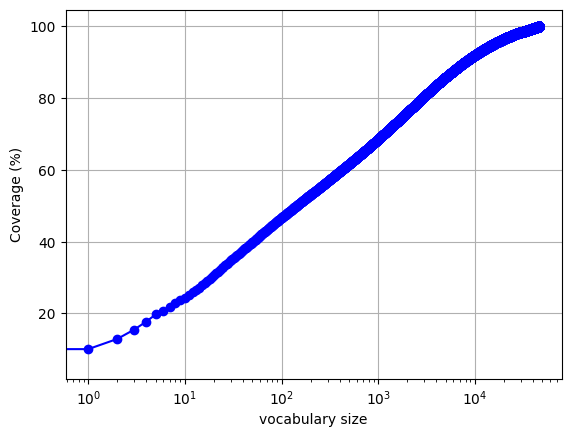

In [4]:
import matplotlib.pyplot as plt
import numpy as np

total_words = sum(count for word, count in filtered_words)

vocab_sizes = []
coverages = []
cumulative = 0

# Take each word
for i in range(len(filtered_words)):
    # Sum with previous cumulative value
    cumulative += filtered_words[i][1]
    counter = 0

    # Calculate coverage
    coverage = cumulative / total_words * 100
    vocab_sizes.append(i)
    coverages.append(coverage)

# Plot
plt.plot(vocab_sizes, coverages, 'bo-')
plt.xscale('log')
plt.xlabel('vocabulary size')
plt.ylabel('Coverage (%)')
plt.grid(True)
plt.show()

In [5]:
# Finding the optimal vocabulary size value (>=90%)
optimal_size = 0
for i, coverage in enumerate(coverages, 1):
    if  coverage >= 90:
        optimal_size = vocab_sizes[i]
        break

vocabulary = filtered_words[:optimal_size]
print("Number of first words to rich the optimal vocabulary size:", optimal_size)

Number of first words to rich the optimal vocabulary size: 7868


# Answers to questions
1) Because when we increase the vocabulary size, we add the most frequent tokens. These tokens cover a large area of the corpus, so coverage grows quickly.
After, we start adding increasingly rare tokens and the vocabulary still continues to gro,. Since rare tokens appear very infrequently, each new token contributes only a small increase in coverage.

2) This phenomenon is explained by Zipf’s Law, which states that the frequency of a word is inversely proportional to its rank in the frequency table.
A small number of words are extremely frequent, while most words are very rare.
For example, if the word 'the' has the first rank and the word 'at' has the second rank, then the word 'the' occurs twice as often as 'at', and so on.

## Task 2: Implement Byte-Pair Encoding (BPE) Tokenizer (4 points)

Implement the [BPE tokenizer](https://arxiv.org/pdf/1508.07909) as the `BPETokenizer` class.

The class should contain correctly implemented:

* `train` method (1.5 points).
* `tokenize` method (1.5 points).

The code should have docstrings and comments (1 point).

In [6]:
class BPE_Tokenizer:

    def __init__(self):
        # Base tokens: letters + word boundary markers
        self.tokens = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm',
                       'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '<w>', '</w>']

        # Maximum vocabulary size
        self.max_tokens_size = 10000

    def train(self, vocabulary):
        # Split words into characters and add boundaries
        vocabulary = [(['<w>'] + list(word) + ['</w>'], freq) for word, freq in vocabulary]

        # Expand vocabulary with merges
        while len(self.tokens) < self.max_tokens_size:
            pairs = {}

            # Count adjacent pair frequencies
            for splitted_word, freq in vocabulary:
                for i in range(len(splitted_word) - 1):
                    if splitted_word[i] == '</w>':
                        break
                    pair = (splitted_word[i], splitted_word[i+1])
                    pairs[pair] = pairs.get(pair, 0) + freq

            if not pairs:
                break

            # Most frequent pair
            best_pair = max(pairs, key=pairs.get)

            if pairs[best_pair] < 2:
                break

            # Create merged token
            new_token = best_pair[0] + best_pair[1]
            self.tokens.append(new_token)

            new_vocabulary = []

            # Replace the best pair by new token
            for splitted_word, freq in vocabulary:
                i = 0
                new_word = []

                while i < len(splitted_word):
                    if (i < len(splitted_word) - 1 and
                        (splitted_word[i], splitted_word[i+1]) == best_pair):

                        new_word.append(new_token)
                        i += 2
                    else:
                        new_word.append(splitted_word[i])
                        i += 1

                new_vocabulary.append((new_word, freq))

            vocabulary = new_vocabulary

    @staticmethod
    def _is_word(token):
        # Check if token contains letters
        return any(ch.isalpha() for ch in token)

    def evalute(self, text):
        # Tokenize sentences
        result = []

        for sent in text:
            new_sent = []

            for element in sent:
                # Keep punctuation as is
                if not self._is_word(element):
                    new_sent.append(element)
                    continue

                # Add word boundaries
                chars = ['<w>'] + list(element) + ['</w>']

                # Longest match search
                i = 0
                word_tokens = []
                n = len(chars)

                while i < n:
                    found = False
                    for j in range(n, i, -1):
                        candidate = ''.join(chars[i:j])
                        if candidate.lower() in self.tokens:
                            word_tokens.append(candidate)
                            i += (j - i)
                            found = True
                            break

                    if not found:
                        word_tokens.append(chars[i])
                        i += 1

                new_sent.extend(word_tokens)

            result.append(new_sent)

        return result

## Task 3: Tokenizer Training and Analysis (3 points)

1. Train the `BPETokenizer` on the Brown corpus with the appropriate vocabulary size selected in Task 1 (1 points)
2. Use the Brown corpus (1000 samples) to calculate the mean and standard deviation of
    * tokenizer's fertility (1 points)
    * length of the tokenized sentence (1 points)

In [7]:
# Train BPE by vocabulary that I create
tokenizer = BPE_Tokenizer()
tokenizer.train(vocabulary)

# Take first 1000 sentences from Brown corpus
all_sent = brown.sents()
all_sent = all_sent[:1000]

# Evalute our BPE
result = tokenizer.evalute(all_sent)

In [9]:
fertilities = []
tokenized_lengths = []

for original_sent, tokenized_sent in zip(all_sent, result):

    # Count words (except punctuation marks)
    word_count = sum(1 for w in original_sent if any(ch.isalpha() for ch in w))

    # Count tokens (except punctuation marks)
    bpe_tokens_count = sum(1 for t in tokenized_sent if any(ch.isalpha() for ch in t))

    # Count fertility
    if word_count > 0:
        fertilities.append(bpe_tokens_count / word_count)

    # Count length of tokenize sentence
    tokenized_lengths.append(len(tokenized_sent))

In [10]:
mean_fertility = np.mean(fertilities)
std_fertility = np.std(fertilities)

mean_length = np.mean(tokenized_lengths)
std_length = np.std(tokenized_lengths)

print("Mean fertility:", mean_fertility)
print("Std fertility:", std_fertility)

print("Mean tokenized sentence length:", mean_length)
print("Std tokenized sentence length:", std_length)

Mean fertility: 1.2647278026114264
Std fertility: 0.31283458620677274
Mean tokenized sentence length: 27.314
Std tokenized sentence length: 15.518292560716851


## Grading Procedure Details

During the grading of the completed assignments, a random set of students will be sampled for the **offline assignment defence**. The defence will be arranged shortly after the assignment submission deadline. The particular date and time will be announced later.

The aim of the assignment defence is to ensure the students understand well their own solutions and know how thier solution works. To check this, the students will be asked various questions about the provided solution. In addition, the students will be asked to run their solution to ensure the solution works without errors.

Examples of questions:

1. How the cumulative coverage is calculated? Why is it called cumulative?
2. What is the rank of a word?
3. How does the BPE tokenizer work? Note: for this question, the students will not be able to see the their own implementation.
4. Why do you consider such vocabulary size appropriate?
5. What is the formula for the fertility of the tokenizer?
6. How do you perform pre-tokenization in your implementation?
7. How do you handle stopwords in the training corpus? Why?
8. etc.

As a result of the assignment defence, the grade for the assignment may be adjusted.